# Denoising Autoencoder (Salt & Pepper) on Oxford-IIIT Pet — PyTorch

Same architecture as the Medium article (plain convolutional autoencoder, **no skip connections**), ported from Keras to PyTorch.

## Plan
| # | Step | What happens |
|---|------|--------------|
| 1 | Setup | Imports, config (image size, noise level, epochs), device |
| 2 | Data | Oxford-IIIT Pet via `torchvision`, resize to 128×128, split into train / val / test |
| 3 | Noise | GPU function adding salt & pepper noise on the fly; visual sanity check |
| 4 | Model | 64-channel encoder and decoder with U-Net skip connections at 64×64 and 128×128, plus Sigmoid output |
| 5 | Train | Adam + BCE (as in the article), fresh noise every batch, track train/val loss |
| 6 | Curves | Plot loss, pick best epoch |
| 7 | Test | PSNR and SSIM on the held-out test split: noisy vs. denoised |
| 8 | Visuals | Noisy / denoised / clean grid |
| 9 | Robustness | Sweep noise density to see how the model copes with levels it wasn't trained on |
| 10 | Baseline | Compare against a 3×3 median filter (the classic S&P fix) |
| 11 | Save | Save and reload weights |

**Differences from the article:** noise is regenerated every batch (not fixed once), salt & pepper replaces Gaussian, and the model is evaluated with PSNR/SSIM as the article's "What Next?" suggests.

## 1. Setup

In [1]:
!pip install -q torchmetrics scipy

import time, random
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torchmetrics.image import StructuralSimilarityIndexMeasure

# ---------------- config ----------------
IMG_SIZE    = 128      # the article uses 240; 128 is faster and lighter on memory
BATCH_SIZE  = 32
EPOCHS      = 30
LR          = 1e-3
TRAIN_NOISE = 0.10     # fraction of pixels corrupted (half salt, half pepper)
VAL_FRAC    = 0.1
SEED        = 42
NUM_WORKERS = 2
# ----------------------------------------

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 54.8 MB/s eta 0:00:00
Device: cuda


## 2. Data — Oxford-IIIT Pet

In [2]:
tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),            # float in [0, 1], shape (3, H, W)
])

full_trainval = datasets.OxfordIIITPet(root="data", split="trainval", target_types="category",
                                       transform=tfm, download=True)
test_ds       = datasets.OxfordIIITPet(root="data", split="test", target_types="category",
                                       transform=tfm, download=True)

n_val = int(len(full_trainval) * VAL_FRAC)
train_ds, val_ds = random_split(full_trainval, [len(full_trainval) - n_val, n_val],
                                generator=torch.Generator().manual_seed(SEED))
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

# labels are ignored: the target is the clean image itself
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

100%|██████████| 792M/792M [00:45<00:00, 17.2MB/s]  
100%|██████████| 19.2M/19.2M [00:02<00:00, 9.19MB/s]


train=3312  val=368  test=3669


## 3. Salt & pepper noise

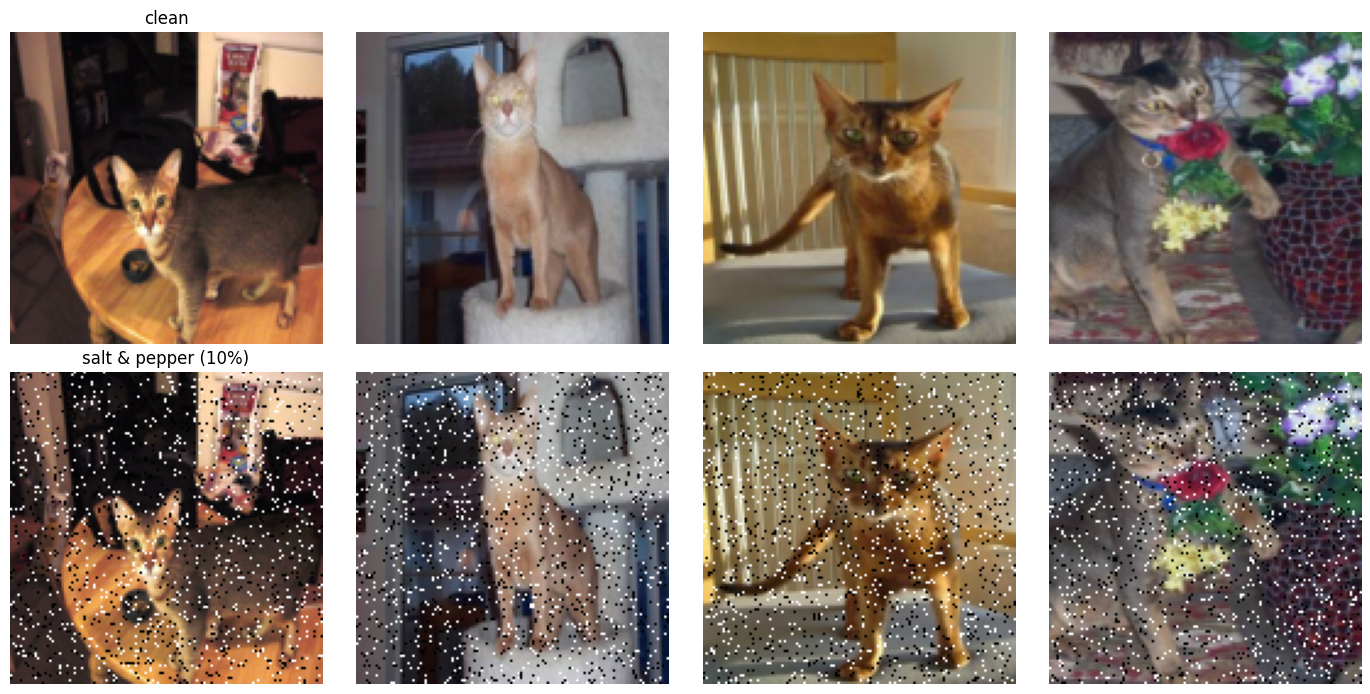

In [3]:
def add_salt_pepper(x, amount=0.10, salt_vs_pepper=0.5, generator=None):
    """x: (B, C, H, W) in [0, 1]. `amount` = fraction of pixels corrupted.
    A corrupted pixel is set to 1 (salt) or 0 (pepper) across all channels."""
    B, C, H, W = x.shape
    r = torch.rand(B, 1, H, W, device=x.device, generator=generator)
    pepper = r < amount * (1 - salt_vs_pepper)
    salt   = (r >= amount * (1 - salt_vs_pepper)) & (r < amount)
    noisy = x.masked_fill(pepper.expand_as(x), 0.0)
    noisy = noisy.masked_fill(salt.expand_as(x), 1.0)
    return noisy

# visual sanity check
x, _ = next(iter(test_loader))
x = x[:4].to(device)
fig, ax = plt.subplots(2, 4, figsize=(14, 7))
for i in range(4):
    ax[0, i].imshow(x[i].permute(1, 2, 0).cpu());                              ax[0, i].axis("off")
    ax[1, i].imshow(add_salt_pepper(x, 0.10)[i].permute(1, 2, 0).cpu());       ax[1, i].axis("off")
ax[0, 0].set_title("clean"); ax[1, 0].set_title("salt & pepper (10%)")
plt.tight_layout(); plt.show()

## 4. Model
Direct port of the article's Keras network. `padding='same'` → `padding=1`; Keras `MaxPooling2D(padding='same')` and `UpSampling2D` map to `MaxPool2d(2)` and `Upsample(scale_factor=2)` (128 → 64 → 32 → 64 → 128, so sizes match exactly).
No skip connections: everything goes through the 32×32×32 bottleneck.

In [4]:
class DenoisingAE(nn.Module):
    def __init__(self, ch=64):
        super().__init__()
        # Encoder: retain features at full and half resolution for skip connections.
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(2)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

        # Decoder: concatenate encoder features at matching resolutions.
        self.dec2 = nn.Sequential(
            nn.Conv2d(ch * 2, ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )
        self.dec1 = nn.Sequential(
            nn.Conv2d(ch * 2, ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch, 3, 3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        e1 = self.enc1(x)                  # (B, 64, 128, 128)
        e2 = self.enc2(self.pool1(e1))     # (B, 64, 64, 64)
        z = self.bottleneck(self.pool2(e2))  # (B, 64, 32, 32)

        d2 = F.interpolate(z, size=e2.shape[-2:], mode="nearest")
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = F.interpolate(d2, size=e1.shape[-2:], mode="nearest")
        return self.dec1(torch.cat([d1, e1], dim=1))

model = DenoisingAE(ch=64).to(device)
print(model)
print("Params:", sum(p.numel() for p in model.parameters()))
with torch.no_grad():
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    print("Bottleneck:", tuple(model.bottleneck(model.pool2(model.enc2(model.pool1(model.enc1(dummy))))).shape), "| Output:", tuple(model(dummy).shape))


DenoisingAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Upsample(scale_factor=2.0, mode='nearest')
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): Upsample(scale_factor=2.0, mode='nearest')
    (6): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Sigmoid()
  )
)
Params: 29507
Bottleneck: (1, 32, 32, 32) | Output: (1, 3, 128, 128)


## 5. Training
BCE loss + Adam, like the article. A new noise pattern is drawn for every batch, so the model never sees the same corruption twice. Validation uses a fixed seed so epochs are comparable.

In [5]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def run_epoch(loader, train, seed=None):
    model.train(train)
    gen = None
    if seed is not None:
        gen = torch.Generator(device=device); gen.manual_seed(seed)
    total, n = 0.0, 0
    with torch.set_grad_enabled(train):
        for clean, _ in loader:
            clean = clean.to(device, non_blocking=True)
            noisy = add_salt_pepper(clean, TRAIN_NOISE, generator=gen)
            out = model(noisy)
            loss = criterion(out, clean)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total += loss.item() * clean.size(0); n += clean.size(0)
    return total / n

history = {"loss": [], "val_loss": []}
best_val = float("inf")

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = run_epoch(train_loader, train=True)
    va = run_epoch(val_loader,   train=False, seed=SEED)
    history["loss"].append(tr); history["val_loss"].append(va)
    
    if va < best_val:
        best_val = va
        torch.save(model.state_dict(), "best_model.pt")
        
    if epoch % 5 == 0:
        torch.save(model.state_dict(), f"model_epoch_{epoch}.pt")
        
    print(f"Epoch {epoch:02d}/{EPOCHS}  train={tr:.4f}  val={va:.4f}  ({time.time()-t0:.0f}s)")

model.load_state_dict(torch.load("best_model.pt"))   # restore best epoch from disk[cite: 1]
print("Best val loss:", round(best_val, 4))

Epoch 01/30  train=0.5839  val=0.5545  (13s)
Epoch 02/30  train=0.5480  val=0.5433  (13s)
Epoch 03/30  train=0.5446  val=0.5412  (13s)
Epoch 04/30  train=0.5429  val=0.5400  (13s)
Epoch 05/30  train=0.5419  val=0.5389  (13s)
Epoch 06/30  train=0.5404  val=0.5377  (13s)
Epoch 07/30  train=0.5390  val=0.5362  (13s)
Epoch 08/30  train=0.5384  val=0.5362  (13s)
Epoch 09/30  train=0.5378  val=0.5354  (13s)
Epoch 10/30  train=0.5374  val=0.5350  (13s)
Epoch 11/30  train=0.5370  val=0.5346  (13s)
Epoch 12/30  train=0.5370  val=0.5343  (13s)
Epoch 13/30  train=0.5364  val=0.5343  (13s)
Epoch 14/30  train=0.5364  val=0.5339  (13s)
Epoch 15/30  train=0.5361  val=0.5336  (13s)
Epoch 16/30  train=0.5359  val=0.5334  (13s)
Epoch 17/30  train=0.5357  val=0.5333  (13s)
Epoch 18/30  train=0.5357  val=0.5332  (13s)
Epoch 19/30  train=0.5356  val=0.5356  (13s)
Epoch 20/30  train=0.5354  val=0.5329  (13s)
Epoch 21/30  train=0.5358  val=0.5328  (13s)
Epoch 22/30  train=0.5354  val=0.5327  (13s)
Epoch 23/3

## 6. Loss curves

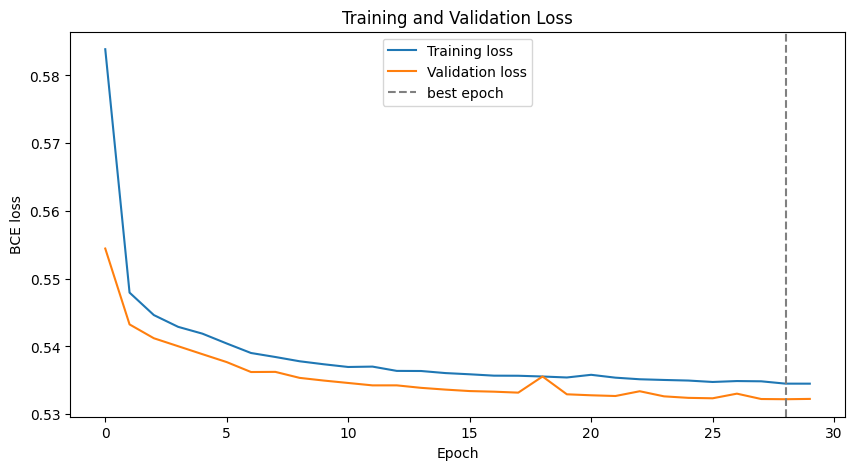

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(history["loss"], label="Training loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.axvline(int(np.argmin(history["val_loss"])), ls="--", c="gray", label="best epoch")
plt.title("Training and Validation Loss"); plt.xlabel("Epoch"); plt.ylabel("BCE loss")
plt.legend(); plt.show()

## 7. Test-set evaluation (PSNR / SSIM)
A fixed seed means the *same* corrupted test images are used every time you run this.

In [7]:
def psnr_batch(a, b):
    mse = ((a - b) ** 2).flatten(1).mean(1).clamp_min(1e-10)
    return 10 * torch.log10(1.0 / mse)          # per-image PSNR, data range [0, 1]

@torch.no_grad()
def evaluate(model, loader, amount, seed=123):
    model.eval()
    gen = torch.Generator(device=device); gen.manual_seed(seed)
    ssim_n = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    ssim_d = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    p_n, p_d = [], []
    for clean, _ in loader:
        clean = clean.to(device)
        noisy = add_salt_pepper(clean, amount, generator=gen)
        den   = model(noisy)
        p_n.append(psnr_batch(noisy, clean)); p_d.append(psnr_batch(den, clean))
        ssim_n.update(noisy, clean);          ssim_d.update(den, clean)
    return dict(psnr_noisy=torch.cat(p_n).mean().item(), psnr_denoised=torch.cat(p_d).mean().item(),
                ssim_noisy=ssim_n.compute().item(),      ssim_denoised=ssim_d.compute().item())

res = evaluate(model, test_loader, TRAIN_NOISE)
print(f"Noise density: {TRAIN_NOISE:.0%}")
print(f"PSNR  noisy: {res['psnr_noisy']:.2f} dB  ->  denoised: {res['psnr_denoised']:.2f} dB")
print(f"SSIM  noisy: {res['ssim_noisy']:.4f}     ->  denoised: {res['ssim_denoised']:.4f}")

Noise density: 10%
PSNR  noisy: 14.92 dB  ->  denoised: 26.62 dB
SSIM  noisy: 0.2651     ->  denoised: 0.7635


## 8. Visual results

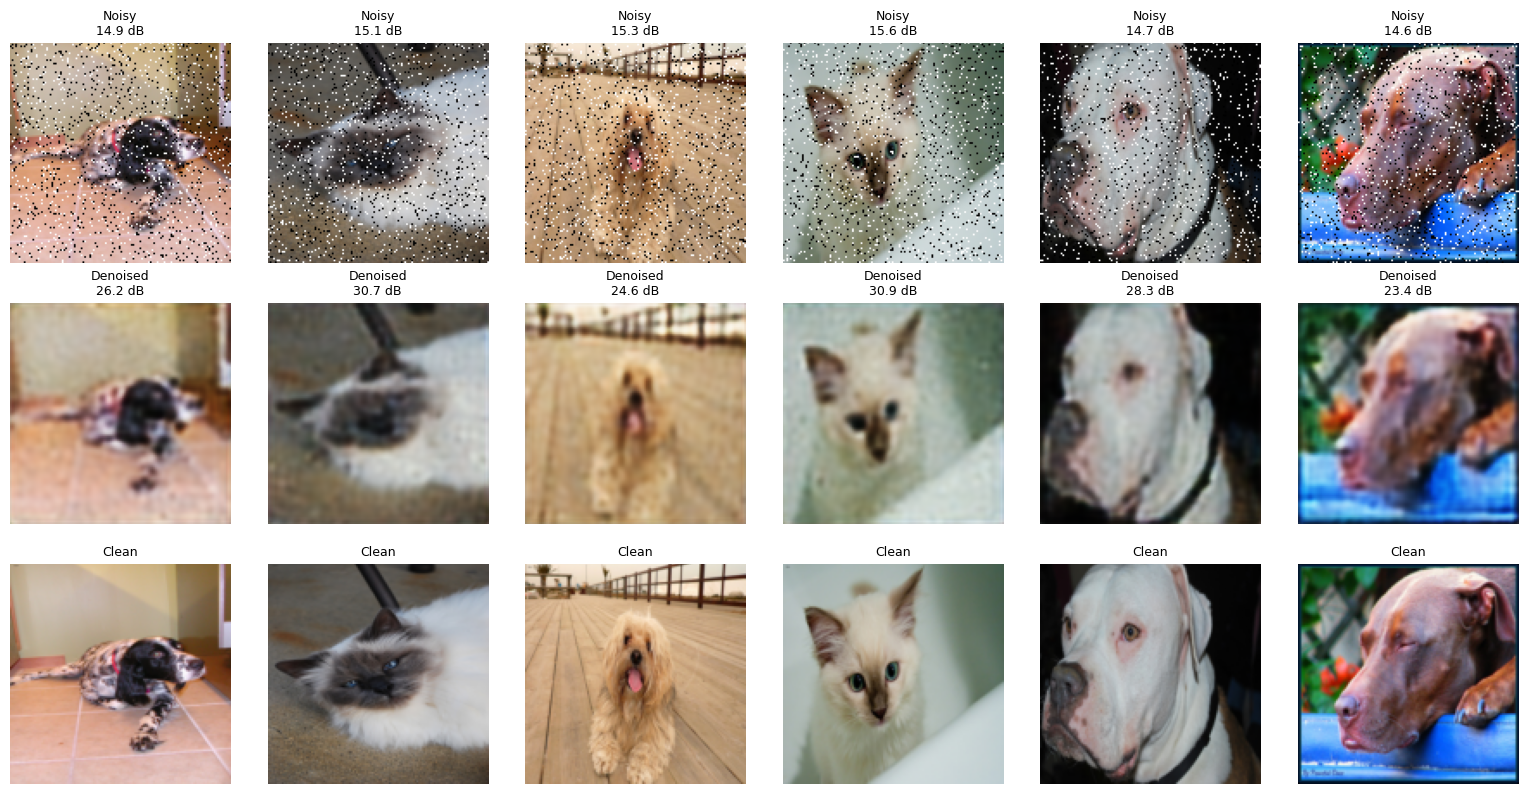

In [8]:
@torch.no_grad()
def show_results(model, dataset, amount=TRAIN_NOISE, n=6, seed=7):
    model.eval()
    idx = random.Random(seed).sample(range(len(dataset)), n)
    clean = torch.stack([dataset[i][0] for i in idx]).to(device)
    gen = torch.Generator(device=device); gen.manual_seed(seed)
    noisy = add_salt_pepper(clean, amount, generator=gen)
    den = model(noisy)
    p_n, p_d = psnr_batch(noisy, clean), psnr_batch(den, clean)

    rows = [("Noisy", noisy, p_n), ("Denoised", den, p_d), ("Clean", clean, None)]
    fig, ax = plt.subplots(3, n, figsize=(2.6 * n, 8))
    for r, (name, imgs, p) in enumerate(rows):
        for c in range(n):
            ax[r, c].imshow(imgs[c].permute(1, 2, 0).clamp(0, 1).cpu()); ax[r, c].axis("off")
            if p is not None: ax[r, c].set_title(f"{name}\n{p[c]:.1f} dB", fontsize=9)
            else:             ax[r, c].set_title(name, fontsize=9)
    plt.tight_layout(); plt.show()

show_results(model, test_ds)

## 9. Robustness: different noise densities
The model was trained at one density. This shows how it behaves on lighter and heavier noise.

  2% | PSNR 21.92 -> 27.04 dB | SSIM 0.689 -> 0.788
  5% | PSNR 17.93 -> 26.99 dB | SSIM 0.444 -> 0.782
 10% | PSNR 14.92 -> 26.62 dB | SSIM 0.265 -> 0.763
 20% | PSNR 11.91 -> 25.05 dB | SSIM 0.140 -> 0.690
 30% | PSNR 10.14 -> 22.74 dB | SSIM 0.090 -> 0.578
 50% | PSNR  7.93 -> 17.77 dB | SSIM 0.044 -> 0.338


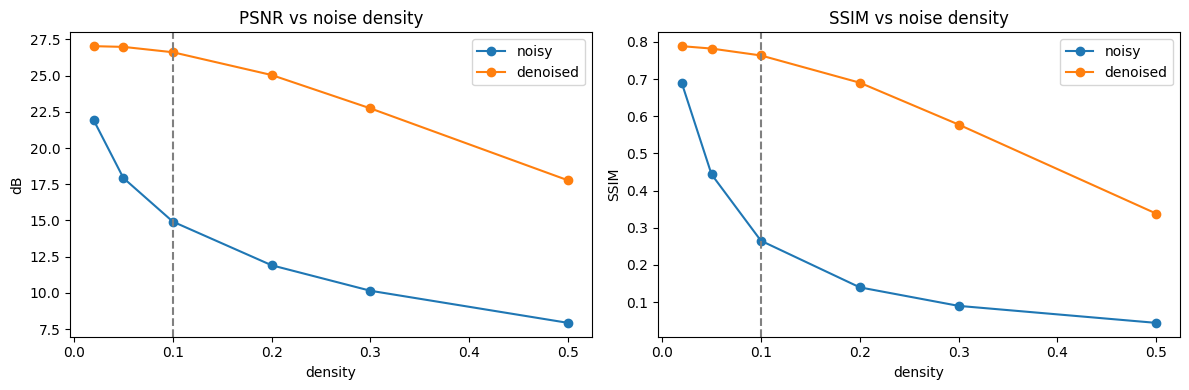

In [10]:
levels = [0.02, 0.05, 0.10, 0.20, 0.30, 0.50]
rows = []
for a in levels:
    r = evaluate(model, test_loader, a)
    rows.append((a, r["psnr_noisy"], r["psnr_denoised"], r["ssim_noisy"], r["ssim_denoised"]))
    print(f"{a:>4.0%} | PSNR {r['psnr_noisy']:5.2f} -> {r['psnr_denoised']:5.2f} dB | SSIM {r['ssim_noisy']:.3f} -> {r['ssim_denoised']:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(levels, [r[1] for r in rows], "o-", label="noisy");    ax[0].plot(levels, [r[2] for r in rows], "o-", label="denoised")
ax[0].axvline(TRAIN_NOISE, ls="--", c="gray"); ax[0].set(title="PSNR vs noise density", xlabel="density", ylabel="dB"); ax[0].legend()
ax[1].plot(levels, [r[3] for r in rows], "o-", label="noisy");    ax[1].plot(levels, [r[4] for r in rows], "o-", label="denoised")
ax[1].axvline(TRAIN_NOISE, ls="--", c="gray"); ax[1].set(title="SSIM vs noise density", xlabel="density", ylabel="SSIM"); ax[1].legend()
plt.tight_layout(); plt.show()

## 10. Baseline: 3×3 median filter
Median filtering is the classic fix for salt & pepper noise. The autoencoder should beat or at least match it; if not, it needs more training or capacity.

Noisy        : 14.84 dB
Median 3x3   : 31.03 dB
Autoencoder  : 26.87 dB


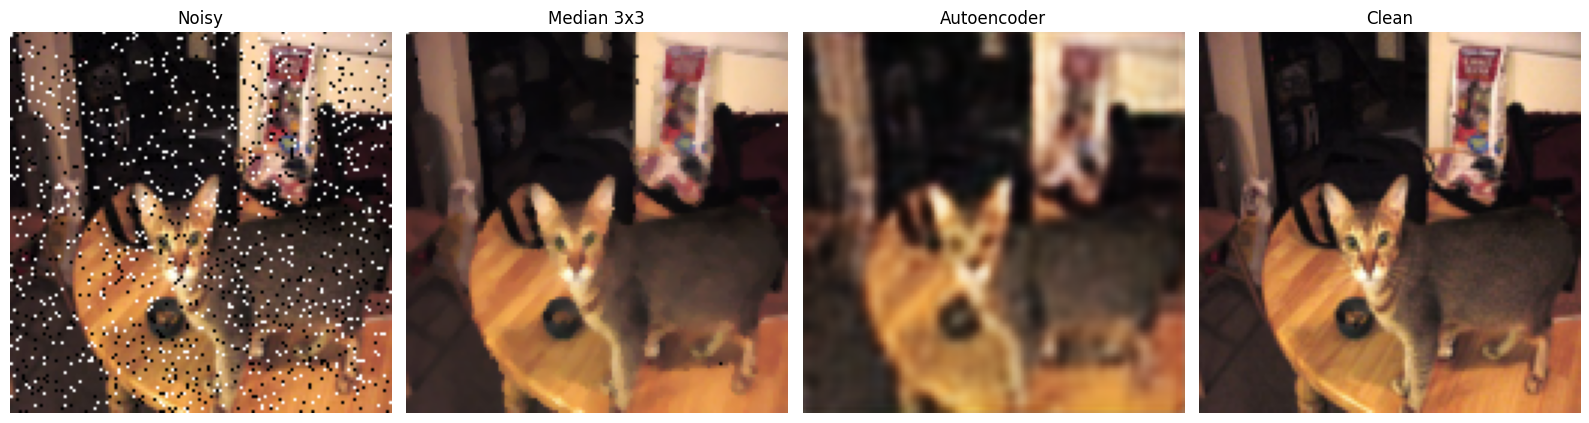

In [11]:
from scipy.ndimage import median_filter

N = 200  # number of test images (CPU filtering is slow)
gen = torch.Generator(device=device); gen.manual_seed(123)
clean = torch.stack([test_ds[i][0] for i in range(N)]).to(device)
noisy = add_salt_pepper(clean, TRAIN_NOISE, generator=gen)

with torch.no_grad():
    model.eval()
    ae_out = torch.cat([model(noisy[i:i+32]) for i in range(0, N, 32)])

med = np.stack([median_filter(img, size=(1, 3, 3)) for img in noisy.cpu().numpy()])   # (N, C, H, W)
med = torch.from_numpy(med).to(device)

print(f"Noisy        : {psnr_batch(noisy, clean).mean():.2f} dB")
print(f"Median 3x3   : {psnr_batch(med,   clean).mean():.2f} dB")
print(f"Autoencoder  : {psnr_batch(ae_out, clean).mean():.2f} dB")

fig, ax = plt.subplots(1, 4, figsize=(16, 4.5))
for a, (t, im) in zip(ax, [("Noisy", noisy[0]), ("Median 3x3", med[0]), ("Autoencoder", ae_out[0]), ("Clean", clean[0])]):
    a.imshow(im.permute(1, 2, 0).clamp(0, 1).cpu()); a.set_title(t); a.axis("off")
plt.tight_layout(); plt.show()

## 11. Save / load

In [ ]:
torch.save({"state_dict": model.state_dict(), "img_size": IMG_SIZE, "train_noise": TRAIN_NOISE}, "dae_saltpepper_pets.pt")

# reload and verify
ckpt = torch.load("dae_saltpepper_pets.pt", map_location=device)
model2 = DenoisingAE().to(device); model2.load_state_dict(ckpt["state_dict"]); model2.eval()
print("Reloaded OK. Test PSNR:", round(evaluate(model2, test_loader, TRAIN_NOISE)["psnr_denoised"], 2), "dB")

## Next steps
- Train with a **random** density per batch (e.g. `amount = random.uniform(0.05, 0.4)`) to improve robustness in section 9.
- Make it a U-Net by concatenating encoder feature maps into the decoder, then re-run sections 7–10 to compare against this baseline.
- Try `nn.MSELoss()` or L1 instead of BCE; they often give higher PSNR for denoising.